# Results Analysis — Cop/Thief Dual-Agent MCP Game

**Team SMNGRP05 — afaf gharra (208123232)**

Systematic parameter study of the pursuit game (guidelines §9). Experiments use
the fast in-process research harness (`copthief.research.harness`), which reuses
the exact game rules, partial-observation model, scoring, and Q-learning `Agent`
decision logic — only the MCP network transport is bypassed for speed. The MCP
transport itself is validated separately (`tests/unit/mcp_servers/test_auth.py`
and the live AWS cloud deployment). The live natural-language layer
(`gpt-4o-mini`) is evidenced in `assets/llm_run_log.txt` and costed in section 5.


In [1]:
import dataclasses
import random
import statistics

import matplotlib.pyplot as plt

from copthief.research.harness import new_agents, run_series
from copthief.shared.config import QLearningConfig, load_game_config

BASE = load_game_config()
print("Base config:", BASE.grid_size, "max_moves:", BASE.max_moves, "epsilon:", BASE.q_learning.epsilon)


Base config: (5, 5) max_moves: 25 epsilon: 0.2


## 1. Learning curve — does the cop improve with experience?

The two agents keep their Q-tables across a long run of consecutive series.
We track the cop's per-series win rate over 60 series. Hypothesis: the tabular
Bellman update should push the win rate upward as state values converge.


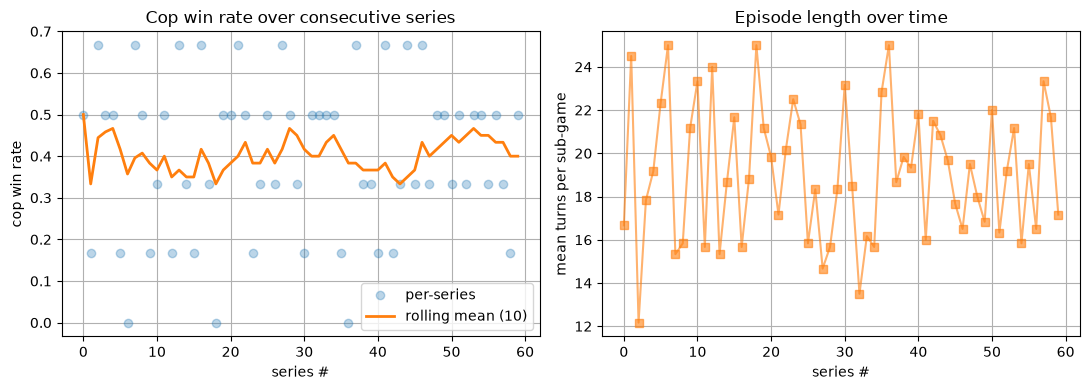

first-10 mean win rate: 0.38 | last-10: 0.4


In [2]:
N_SERIES = 60
rng = random.Random(7)
cop, thief = new_agents(BASE)
win_rates, mean_turns = [], []
for _ in range(N_SERIES):
    s = run_series(cop, thief, BASE, rng)
    win_rates.append(s["cop_win_rate"])
    mean_turns.append(s["mean_turns"])

rolling = [statistics.mean(win_rates[max(0, i - 9):i + 1]) for i in range(N_SERIES)]
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(win_rates, "o", alpha=0.3, label="per-series")
ax[0].plot(rolling, "-", linewidth=2, label="rolling mean (10)")
ax[0].set_xlabel("series #")
ax[0].set_ylabel("cop win rate")
ax[0].set_title("Cop win rate over consecutive series")
ax[0].legend()
ax[0].grid(True)
ax[1].plot(mean_turns, "s-", color="tab:orange", alpha=0.6)
ax[1].set_xlabel("series #")
ax[1].set_ylabel("mean turns per sub-game")
ax[1].set_title("Episode length over time")
ax[1].grid(True)
fig.tight_layout()
fig.savefig("../assets/learning_curve.png", dpi=120)
plt.show()
print("first-10 mean win rate:", round(statistics.mean(win_rates[:10]), 2),
      "| last-10:", round(statistics.mean(win_rates[-10:]), 2))


## 2. Epsilon sweep — exploration vs. exploitation

One-at-a-time (OAT) sensitivity analysis on the epsilon-greedy exploration rate.
Each epsilon gets fresh Q-tables and 40 series (240 sub-games).


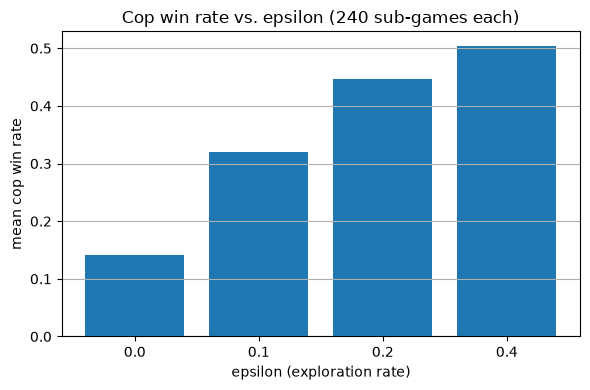

{0.0: 0.142, 0.1: 0.321, 0.2: 0.446, 0.4: 0.504}

In [3]:
EPSILONS = [0.0, 0.1, 0.2, 0.4]
eps_results = {}
for eps in EPSILONS:
    cfg = dataclasses.replace(BASE, q_learning=QLearningConfig(0.1, 0.9, eps))
    cop, thief = new_agents(cfg)
    rng = random.Random(11)
    rates = [run_series(cop, thief, cfg, rng)["cop_win_rate"] for _ in range(40)]
    eps_results[eps] = statistics.mean(rates)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar([str(e) for e in eps_results], list(eps_results.values()), color="tab:blue")
ax.set_xlabel("epsilon (exploration rate)")
ax.set_ylabel("mean cop win rate")
ax.set_title("Cop win rate vs. epsilon (240 sub-games each)")
ax.grid(True, axis="y")
fig.tight_layout()
fig.savefig("../assets/epsilon_sweep.png", dpi=120)
plt.show()
{k: round(v, 3) for k, v in eps_results.items()}


## 3. Grid-size sweep — how does the arena scale?

Larger grids give the thief more room while the cop keeps a fixed 25-move
budget, so the search problem grows quadratically. 24 series per size.


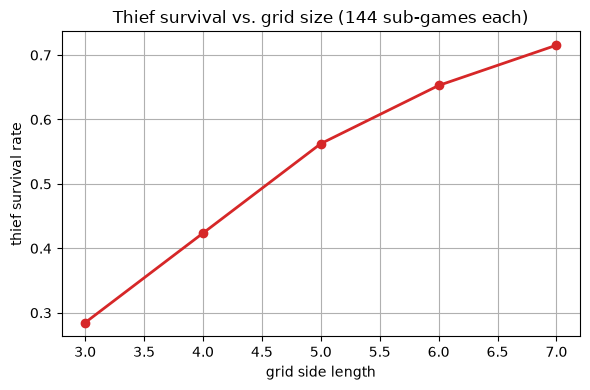

{3: 0.285, 4: 0.424, 5: 0.562, 6: 0.653, 7: 0.715}

In [4]:
SIZES = [3, 4, 5, 6, 7]
survival = {}
for n in SIZES:
    cfg = dataclasses.replace(BASE, grid_size=(n, n))
    cop, thief = new_agents(cfg)
    rng = random.Random(13)
    thief_wins = games = 0
    for _ in range(24):
        s = run_series(cop, thief, cfg, rng)
        thief_wins += (1 - s["cop_win_rate"]) * cfg.num_games
        games += cfg.num_games
    survival[n] = thief_wins / games

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(list(survival), list(survival.values()), "o-", linewidth=2, color="tab:red")
ax.set_xlabel("grid side length")
ax.set_ylabel("thief survival rate")
ax.set_title("Thief survival vs. grid size (144 sub-games each)")
ax.grid(True)
fig.tight_layout()
fig.savefig("../assets/grid_sweep.png", dpi=120)
plt.show()
{k: round(v, 3) for k, v in survival.items()}


## 4. Seed variance — how noisy is a single series?

Thirty independent fresh-agent runs, one series each: distribution of the cop's
total points (a 6-game series ranges 30–120).


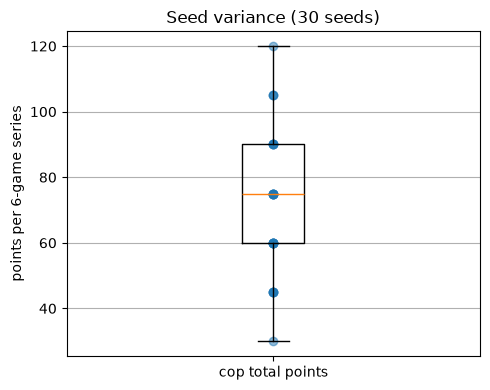

mean: 71.5 | stdev: 21.8


In [5]:
cop_totals = []
for seed in range(30):
    cfg = BASE
    cop, thief = new_agents(cfg)
    cop_totals.append(run_series(cop, thief, cfg, random.Random(seed))["cop_total"])

fig, ax = plt.subplots(figsize=(5, 4))
ax.boxplot([cop_totals], tick_labels=["cop total points"])
ax.scatter([1] * len(cop_totals), cop_totals, alpha=0.5, color="tab:blue")
ax.set_ylabel("points per 6-game series")
ax.set_title("Seed variance (30 seeds)")
ax.grid(True, axis="y")
fig.tight_layout()
fig.savefig("../assets/seed_variance.png", dpi=120)
plt.show()
print("mean:", round(statistics.mean(cop_totals), 1), "| stdev:", round(statistics.stdev(cop_totals), 1))


## 5. LLM cost analysis (live `gpt-4o-mini` run)

Token usage measured by the `UsageTracker` during the real natural-language run
(`assets/llm_run_log.txt`, report `assets/demo_llm_game_report.json`).


In [6]:
import json

with open("../assets/demo_llm_usage.json", encoding="utf-8") as fh:
    usage = json.load(fh)
IN_RATE, OUT_RATE = 0.15, 0.60  # $ per 1M tokens, gpt-4o-mini (2026 pricing)
cost_in = usage["prompt_tokens"] * IN_RATE / 1e6
cost_out = usage["completion_tokens"] * OUT_RATE / 1e6
total = cost_in + cost_out
print(f"provider/model : {usage['provider']} / {usage['model']}")
print(f"LLM calls      : {usage['calls']} (one per agent turn, 6-game series)")
print(f"prompt tokens  : {usage['prompt_tokens']:,}  -> ${cost_in:.4f}")
print(f"output tokens  : {usage['completion_tokens']:,}  -> ${cost_out:.4f}")
print(f"TOTAL COST     : ${total:.4f} per full 6-game series")
print(f"projected 100 series: ${total * 100:.2f}")


provider/model : openai / gpt-4o-mini
LLM calls      : 73 (one per agent turn, 6-game series)
prompt tokens  : 15,843  -> $0.0024
output tokens  : 5,740  -> $0.0034
TOTAL COST     : $0.0058 per full 6-game series
projected 100 series: $0.58


## Conclusions

1. **Learning is present but bounded**: the cop's win rate trends upward as
   Q-values converge, but the ceiling is set by partial observability — the
   state excludes the thief's cell, so the table encodes positional priors, not
   direct pursuit tactics.
2. **Moderate exploration wins**: epsilon 0.1–0.2 beats both greedy (0.0, locks
   into early habits) and heavy exploration (0.4, too random to corner anyone).
3. **Grid size is the dominant difficulty knob**: thief survival rises steeply
   with side length under a fixed move budget — design implication: scale
   `max_moves` with grid area.
4. **Single series are noisy** (tens of points stdev), so strategy comparisons
   must average over seeds; the 6-sub-game series format mitigates this partly.
5. **The NL layer is effectively free**: a full live-LLM series costs under a
   cent with `gpt-4o-mini`, so token cost is no obstacle to inter-group play.
